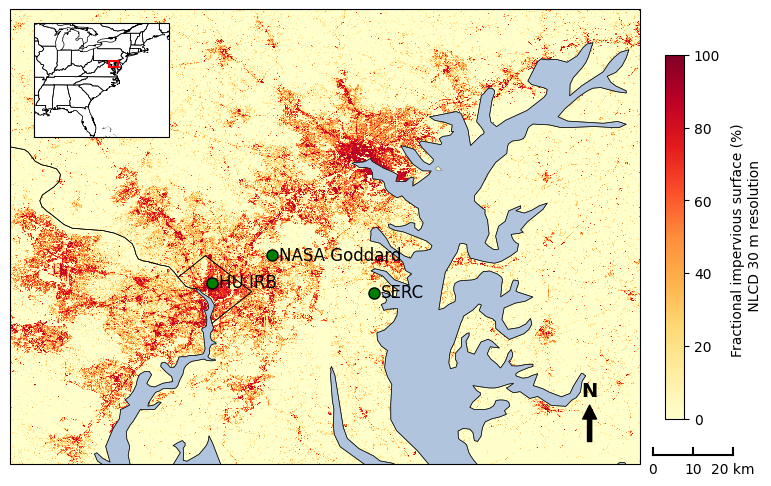

In [47]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.patches as mpatches
import numpy as np
import rioxarray

main_extent = [-77.6, -75.8, 38.4, 39.7]
inset_extent = [-92.0, -66.0, 25.0, 47.0]

sites = {
    "NASA Goddard": (38.9977, -76.8525),
    "HU IRB":       (38.9193, -77.0215),
    "SERC":         (38.890131, -76.560014),
}

fig = plt.figure(figsize=(9, 12))
ax = fig.add_axes([0.1, 0.1, 0.7, 0.8], projection=ccrs.PlateCarree())
ax.set_extent(main_extent, crs=ccrs.PlateCarree())

tif_path = "/Users/ujjawal/Downloads/Ceilometer Script/data/Annual_NLCD_FctImp_2024_CU_C1V1_73500eef-4690-4280-b48a-9188b6681a2a.tiff"
raster = rioxarray.open_rasterio(tif_path)
raster = raster.rio.reproject("EPSG:4326")

min_lon, max_lon, min_lat, max_lat = main_extent
raster_clipped = raster.rio.clip_box(minx=min_lon, miny=min_lat, maxx=max_lon, maxy=max_lat)

lons = raster_clipped.x.values
lats = raster_clipped.y.values
lon_grid, lat_grid = np.meshgrid(lons, lats)
z = raster_clipped.squeeze().values

z = np.where((z < 0) | (z > 100), np.nan, z)

im = ax.pcolormesh(lon_grid, lat_grid, z, transform=ccrs.PlateCarree(), 
                   cmap='YlOrRd', vmin=0, vmax=100, shading='auto')

water_color = '#B0C4DE' 
ocean = cfeature.NaturalEarthFeature('physical', 'ocean', '10m', 
                                     facecolor=water_color, edgecolor='gray', linewidth=0.5)
lakes = cfeature.NaturalEarthFeature('physical', 'lakes', '10m', 
                                     facecolor=water_color, edgecolor='gray', linewidth=0.5)

ax.add_feature(ocean, zorder=2)
ax.add_feature(lakes, zorder=2)
ax.add_feature(cfeature.STATES.with_scale('10m'), linewidth=0.5, zorder=3, edgecolor='black', facecolor='none')

for site, (lat, lon) in sites.items():
    ax.plot(lon, lat, marker='o', color='green', markersize=8, 
            markeredgecolor='black', transform=ccrs.PlateCarree(), zorder=5)
    ax.text(lon + 0.02, lat, site, transform=ccrs.PlateCarree(),
            fontsize=12, ha='left', va='center',
            zorder=6)

inset_ax = ax.inset_axes([0.02, 0.72, 0.25, 0.25], projection=ccrs.PlateCarree())
inset_ax.set_extent(inset_extent, crs=ccrs.PlateCarree())

inset_ax.add_feature(cfeature.LAND, facecolor='white', edgecolor='black', linewidth=0.5)
inset_ax.add_feature(cfeature.OCEAN, facecolor='white')
inset_ax.add_feature(cfeature.STATES, linewidth=0.5)

rect = mpatches.Rectangle((main_extent[0], main_extent[2]), 
                          main_extent[1] - main_extent[0], 
                          main_extent[3] - main_extent[2],
                          linewidth=1.5, edgecolor='red', facecolor='none',
                          transform=ccrs.PlateCarree(), zorder=10)
inset_ax.add_patch(rect)

cbar_ax = ax.inset_axes([1.04, 0.1, 0.03, 0.8])
cbar = plt.colorbar(im, cax=cbar_ax, orientation='vertical')
cbar.set_label('Fractional impervious surface (%) \n NLCD 30 m resolution', fontsize=10, labelpad=8)
cbar.set_ticks([0, 20, 40, 60, 80, 100])

ax.text(0.92, 0.15, 'N', transform=ax.transAxes, fontsize=14, fontweight='bold', ha='center')
ax.annotate('', xy=(0.92, 0.13), xytext=(0.92, 0.05), xycoords='axes fraction',
            arrowprops=dict(facecolor='black', width=3, headwidth=10, headlength=10),
            ha='center', va='center')

# Shifted scale bar to the right
bar_x_start = 1.02
bar_y = 0.02
bar_width = 0.128

ax.plot([bar_x_start, bar_x_start + bar_width], [bar_y, bar_y], 
        color='black', linewidth=1.5, transform=ax.transAxes, clip_on=False)

tick_x = [bar_x_start, bar_x_start + bar_width / 2, bar_x_start + bar_width]
labels = ['0', '10', '20 km']
for x, label in zip(tick_x, labels):
    ax.plot([x, x], [bar_y, bar_y + 0.015], color='black', linewidth=1.5, 
            transform=ax.transAxes, clip_on=False)
    ax.text(x, bar_y - 0.015, label, transform=ax.transAxes, 
            ha='center', va='top', fontsize=10)

plt.savefig('../data/impervious_surface_map.png', dpi=300, bbox_inches='tight')
plt.show()

In [48]:
import os
import ssl
import requests
import datetime

# Fix SSL issues for secure downloads
if (not os.environ.get('PYTHONHTTPSVERIFY', '') and getattr(ssl, '_create_unverified_context', None)):
    ssl._create_default_https_context = ssl._create_unverified_context

# Mapping of custom site names to AERONET official site names
site_name_map = {
    "GSFC": "GSFC",
    "HU_IRB": "Howard_Univ-IRB",
    "SERC": "SERC"
}

# User-defined parameters
sites = ["GSFC", "HU_IRB", "SERC"]
levels = ["15", "20"]
products = ["directsun"]
start_year = 2020
end_year = 2025
avg = 10 

# Get current date
now = datetime.datetime.now()
current_year = now.year
current_month = now.month
current_day = now.day

# Loop through sites and years to download data
for aeronet_site in sites:
    site = site_name_map[aeronet_site]
    
    # --- UPDATED PATH ---
    # Goes up one level, into 'data', then organizes by site and 'Raw'
    save_dir = os.path.join("..", "data", aeronet_site, "Raw")
    os.makedirs(save_dir, exist_ok=True)

    for year in range(start_year, end_year + 1):
        month_start, day_start = "01", "01"

        if year == current_year:
            month_end = f"{current_month:02d}"
            day_end = f"{current_day:02d}"
        else:
            month_end, day_end = "12", "31"

        for level in levels:
            for product in products:
                url = (f"https://aeronet.gsfc.nasa.gov/cgi-bin/print_web_data_v3?site={site}"
                       f"&year={year}&month={month_start}&day={day_start}"
                       f"&year2={year}&month2={month_end}&day2={day_end}"
                       f"&AOD{level}=1&AVG={avg}&if_no_html=1")

                filename = f"{aeronet_site}_raw_{year}_AOD{level}_{product}.csv"
                filepath = os.path.join(save_dir, filename)

                print(f"\n🔹 Checking: {filename}")

                try:
                    response = requests.get(url)
                    response.raise_for_status()

                    if "No Data" in response.text or len(response.text.strip()) < 50:
                        print(f"No valid data found for {year} (AOD {level}). Skipping...")
                        continue

                    with open(filepath, "w") as file:
                        file.write(response.text)

                    print(f"✅ Data saved to: {filepath}")
                except Exception as e:
                    print(f"❌ Failed to download {filename}. Error: {e}")

print("\nAll downloads completed!")


🔹 Checking: GSFC_raw_2020_AOD15_directsun.csv
✅ Data saved to: ../data/GSFC/Raw/GSFC_raw_2020_AOD15_directsun.csv

🔹 Checking: GSFC_raw_2020_AOD20_directsun.csv
✅ Data saved to: ../data/GSFC/Raw/GSFC_raw_2020_AOD20_directsun.csv

🔹 Checking: GSFC_raw_2021_AOD15_directsun.csv
✅ Data saved to: ../data/GSFC/Raw/GSFC_raw_2021_AOD15_directsun.csv

🔹 Checking: GSFC_raw_2021_AOD20_directsun.csv
✅ Data saved to: ../data/GSFC/Raw/GSFC_raw_2021_AOD20_directsun.csv

🔹 Checking: GSFC_raw_2022_AOD15_directsun.csv
✅ Data saved to: ../data/GSFC/Raw/GSFC_raw_2022_AOD15_directsun.csv

🔹 Checking: GSFC_raw_2022_AOD20_directsun.csv
✅ Data saved to: ../data/GSFC/Raw/GSFC_raw_2022_AOD20_directsun.csv

🔹 Checking: GSFC_raw_2023_AOD15_directsun.csv
✅ Data saved to: ../data/GSFC/Raw/GSFC_raw_2023_AOD15_directsun.csv

🔹 Checking: GSFC_raw_2023_AOD20_directsun.csv
✅ Data saved to: ../data/GSFC/Raw/GSFC_raw_2023_AOD20_directsun.csv

🔹 Checking: GSFC_raw_2024_AOD15_directsun.csv
✅ Data saved to: ../data/GSFC/Raw

In [49]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(
    "/Users/ujjawal/Downloads/Ceilometer Script/data/HU_IRB/Raw/HU_IRB_raw_2021_AOD15_directsun.csv",
    skiprows=5,
    na_values=["-999", "-999.000000"]
)

print("Shape:", df.shape)
print("\nAll columns:")
print(df.columns.tolist())
print("\nStats:")
display(df.describe())


Shape: (551, 114)

All columns:
['AERONET_Site', 'Date(dd:mm:yyyy)', 'Time(hh:mm:ss)', 'Day_of_Year', 'Day_of_Year(Fraction)', 'AOD_1640nm', 'AOD_1020nm', 'AOD_870nm', 'AOD_865nm', 'AOD_779nm', 'AOD_675nm', 'AOD_667nm', 'AOD_620nm', 'AOD_560nm', 'AOD_555nm', 'AOD_551nm', 'AOD_532nm', 'AOD_531nm', 'AOD_510nm', 'AOD_500nm', 'AOD_490nm', 'AOD_443nm', 'AOD_440nm', 'AOD_412nm', 'AOD_400nm', 'AOD_380nm', 'AOD_340nm', 'Precipitable_Water(cm)', 'AOD_681nm', 'AOD_709nm', 'AOD_Empty', 'AOD_Empty.1', 'AOD_Empty.2', 'AOD_Empty.3', 'AOD_Empty.4', 'Triplet_Variability_1640', 'Triplet_Variability_1020', 'Triplet_Variability_870', 'Triplet_Variability_865', 'Triplet_Variability_779', 'Triplet_Variability_675', 'Triplet_Variability_667', 'Triplet_Variability_620', 'Triplet_Variability_560', 'Triplet_Variability_555', 'Triplet_Variability_551', 'Triplet_Variability_532', 'Triplet_Variability_531', 'Triplet_Variability_510', 'Triplet_Variability_500', 'Triplet_Variability_490', 'Triplet_Variability_443',

,Day_of_Year,Day_of_Year(Fraction),AOD_1640nm,AOD_1020nm,AOD_870nm,AOD_865nm,AOD_779nm,AOD_675nm,AOD_667nm,AOD_620nm,...,Exact_Wavelengths_of_AOD(um)_380nm,Exact_Wavelengths_of_AOD(um)_340nm,Exact_Wavelengths_of_PW(um)_935nm,Exact_Wavelengths_of_AOD(um)_681nm,Exact_Wavelengths_of_AOD(um)_709nm,Exact_Wavelengths_of_AOD(um)_Empty,Exact_Wavelengths_of_AOD(um)_Empty.1,Exact_Wavelengths_of_AOD(um)_Empty.2,Exact_Wavelengths_of_AOD(um)_Empty.3,Exact_Wavelengths_of_AOD(um)_Empty.4
count,551.000000,551.000000,551.000000,551.000000,551.000000,0.0,0.0,550.000000,0.0,0.0,...,5.480000e+02,5.480000e+02,5.510000e+02,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,65.989111,66.720654,0.016063,0.022007,0.027473,NaN,NaN,0.037173,NaN,NaN,...,3.797000e-01,3.398000e-01,9.367000e-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,2.868619,2.824540,0.019214,0.022550,0.023589,NaN,NaN,0.026692,NaN,NaN,...,5.556187e-17,5.556187e-17,1.111232e-16,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,60.000000,60.789387,0.004674,0.006042,0.009602,NaN,NaN,0.011297,NaN,NaN,...,3.797000e-01,3.398000e-01,9.367000e-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,64.000000,64.620394,0.007710,0.010424,0.014899,NaN,NaN,0.021418,NaN,NaN,...,3.797000e-01,3.398000e-01,9.367000e-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,66.000000,66.840544,0.011082,0.014785,0.019063,NaN,NaN,0.027605,NaN,NaN,...,3.797000e-01,3.398000e-01,9.367000e-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,67.000000,67.926412,0.016351,0.025720,0.033701,NaN,NaN,0.047182,NaN,NaN,...,3.797000e-01,3.398000e-01,9.367000e-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,73.000000,73.696875,0.123961,0.144211,0.150880,NaN,NaN,0.169964,NaN,NaN,...,3.797000e-01,3.398000e-01,9.367000e-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN
